In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

checkpoint_dfs = []
checkpoints = [50000, 100000, 150000, 200000]
seeds = [42, 67, 888]

seed_ckpts = [ [42, 50000], [42, 100000], [42, 150000], [42, 200000], [67, 50000], [67, 100000], [67, 150000], [67, 200000], [888, 50000], [888, 100000], [888, 150000], [888, 200000] ]

for seed in seeds:
    for ckpt in checkpoints:
        df = pd.read_csv(f"../per_model/ckpt_seed{seed}_checkpoint{ckpt}_test_results.csv")
        checkpoint_dfs.append(df)

print(len(checkpoint_dfs))

errors_only = df[df["is_error"] == True]

print(len(errors_only))


12
318


Below are definitions for the functions needed for evaluation

In [37]:
from collections import defaultdict, Counter

def align_trxn(seqA, seqB):
    """Returns two aligned transcriptions (each a list of phones) and their edit distance given two unaligned transcriptions."""

    lenA = len(seqA)
    lenB = len(seqB)

    score_matrix        = [[0 for _ in range(lenB+1)] for _ in range(lenA+1)]
    traceback_matrix    = [[0 for _ in range(lenB+1)] for _ in range(lenA+1)]

    # define substitution scores and gap penalty
    match       = +1
    mismatch    = -1
    gap         = -1

    # initialize scoring matrix
    for i in range(lenA+1):
        score_matrix[i][0] = i*gap  # rows: seqA
    for j in range(lenB+1):
        score_matrix[0][j] = j*gap  # cols: seqB

    # fill scoring matrix
    for i in range(1, lenA+1):
        for j in range(1, lenB+1):
            if seqA[i-1] == seqB[j-1]:
                score = match
            else:
                score = mismatch

            # final score choices
            aligned     = score_matrix[i-1][j-1] + score
            deleted     = score_matrix[i-1][j  ] + gap
            inserted    = score_matrix[i  ][j-1] + gap

            score_matrix[i][j] = max(aligned, deleted, inserted)

            if score_matrix[i][j] == aligned:
                traceback_matrix[i][j] = 0  # phones i and j aligned
            elif score_matrix[i][j] == deleted:
                traceback_matrix[i][j] = 1  # gap in seqB
            elif score_matrix[i][j] == inserted:
                traceback_matrix[i][j] = -1 # gap in seqA

    # print(score_matrix)

    # get aligned sequences from traceback matrix
    i, j = lenA, lenB
    alnseqA, alnseqB = list(), list()
    edit_distance = 0
    ops = []

    while (i > 0 and j > 0):
        if traceback_matrix[i][j] == 0:
            alnseqA.append(seqA[i-1])
            alnseqB.append(seqB[j-1])
            ops.append((seqA[i-1], seqB[j-1]))
            if seqA[i-1] != seqB[j-1]:
                edit_distance += 1
            i -= 1
            j -= 1
        elif traceback_matrix[i][j] == 1:
            alnseqA.append(seqA[i-1])
            alnseqB.append('*')
            ops.append((seqA[i-1], "*"))
            edit_distance += 1
            i -= 1
        elif traceback_matrix[i][j] == -1:
            alnseqA.append('*')
            alnseqB.append(seqB[j-1])

            ops.append(("*", seqB[j-1]))

            edit_distance += 1
            j -= 1
    while i > 0:
        alnseqA.append(seqA[i-1])
        alnseqB.append('*')

        ops.append((seqA[i-1], "*"))

        edit_distance += 1
        i -= 1
    while j > 0:
        alnseqA.append('*')
        alnseqB.append(seqB[j-1])

        ops.append(("*", seqB[j-1]))


        edit_distance += 1
        j -= 1

    # reverse sequences to original orders
    alnseqA = alnseqA[::-1]
    alnseqB = alnseqB[::-1]
    ops = ops[::-1]

    # print(alnseqA)
    # print(alnseqB)
    # print('edit distance: ', edit_distance)
    return [alnseqA, alnseqB, edit_distance, ops]


_MAX_EXAMPLES = 5

def collect_errors(ref, hyp):
    """Collect substitution, deletion, and insertion statistics across all word pairs.

    Returns a dict with:
        n_sub, n_del, n_ins          – total counts per error type
        sub_ref_counter              – Counter of ref phones involved in substitutions
        sub_hyp_counter              – Counter of hyp phones involved in substitutions
        del_counter                  – Counter of deleted ref phones
        ins_counter                  – Counter of inserted hyp phones
        sub_pair_counter             – Counter of (ref_phone, hyp_phone) substitution pairs
        sub_ref_examples             – {phone: [example dicts]} up to _MAX_EXAMPLES each
        sub_hyp_examples             – {phone: [example dicts]} up to _MAX_EXAMPLES each
        del_examples                 – {phone: [example dicts]} up to _MAX_EXAMPLES each
        ins_examples                 – {phone: [example dicts]} up to _MAX_EXAMPLES each
        sub_pair_examples            – {(r,h): [example dicts]} up to _MAX_EXAMPLES each

    Each example dict: {'word': str, 'ref': str, 'hyp': str, 'op': str}
    Only words present in both ref and hyp are evaluated.
    """
    n_sub = n_del = n_ins = 0
    sub_ref_counter  = Counter()
    sub_hyp_counter  = Counter()
    del_counter      = Counter()
    ins_counter      = Counter()
    sub_pair_counter = Counter()

    sub_ref_examples  = defaultdict(list)
    sub_hyp_examples  = defaultdict(list)
    del_examples      = defaultdict(list)
    ins_examples      = defaultdict(list)
    sub_pair_examples = defaultdict(list)

    for word, ref_phones in ref.items():
        if word not in hyp:
            continue
        hyp_phones = hyp[word]
        _, _, _, ops = align_trxn(ref_phones, hyp_phones)

        base = {
            'word': word,
            'ref':  ' '.join(ref_phones),
            'hyp':  ' '.join(hyp_phones),
        }

        for (r, h) in ops:
            if r == '*':
                n_ins += 1
                ins_counter[h] += 1
                if len(ins_examples[h]) < _MAX_EXAMPLES:
                    ins_examples[h].append({**base, 'op': f'ins({h})'})
            elif h == '*':
                n_del += 1
                del_counter[r] += 1
                if len(del_examples[r]) < _MAX_EXAMPLES:
                    del_examples[r].append({**base, 'op': f'del({r})'})
            elif r != h:
                n_sub += 1
                sub_ref_counter[r] += 1
                sub_hyp_counter[h] += 1
                sub_pair_counter[(r, h)] += 1
                if len(sub_ref_examples[r]) < _MAX_EXAMPLES:
                    sub_ref_examples[r].append({**base, 'op': f'sub({r}→{h})'})
                if len(sub_hyp_examples[h]) < _MAX_EXAMPLES:
                    sub_hyp_examples[h].append({**base, 'op': f'sub({r}→{h})'})
                pair = (r, h)
                if len(sub_pair_examples[pair]) < _MAX_EXAMPLES:
                    sub_pair_examples[pair].append({**base, 'op': f'sub({r}→{h})'})

    return {
        'n_sub': n_sub,
        'n_del': n_del,
        'n_ins': n_ins,
        'sub_ref_counter':  sub_ref_counter,
        'sub_hyp_counter':  sub_hyp_counter,
        'del_counter':      del_counter,
        'ins_counter':      ins_counter,
        'sub_pair_counter': sub_pair_counter,
        'sub_ref_examples':  dict(sub_ref_examples),
        'sub_hyp_examples':  dict(sub_hyp_examples),
        'del_examples':      dict(del_examples),
        'ins_examples':      dict(ins_examples),
        'sub_pair_examples': dict(sub_pair_examples),
    }

In [38]:
def top5(counter, label):
    #print(f"--- {label} ---")
    return pd.DataFrame([{"Phone": p, "Count": c} for p, c in counter.most_common(5)])

GLOTTAL = "ʔ"
_MAX_POS_EXAMPLES = 8


def _pos_bucket(idx, n):
    """Classify a phone index within a word of length n."""
    if idx == 0:
        return "initial"
    if idx == n - 1:
        return "final"
    return "medial"

def _pos_table(counter, label):
    total = sum(counter.values())
    rows = []
    for pos in ("initial", "medial", "final"):
        c = counter[pos]
        pct = f"{c / total * 100:.1f}%" if total else "-"
        rows.append({"Position": pos, "Count": c, "% of ʔ errors": pct})
    rows.append({"Position": "TOTAL", "Count": total, "% of ʔ errors": "100.0%"})
    print(f"--- {label} ---")
    return pd.DataFrame(rows)

In [39]:
import unicodedata
_DEFAULT_VOWEL_GROUPS = {"o/u": {"o", "u"}, "e/i": {"e", "i"}}
_LENGTH   = 'ː'  


def _base_vowel(ph):
    """Strip combining marks and the length modifier (ː) so oː/õ fold to o."""
    return ''.join(
        c for c in ph
        if not unicodedata.category(c).startswith('M') and c != _LENGTH
    )


def vowel_confusion(ref, hyp, groups=None):
    """Count directed vowel-height substitutions per group (e.g. o↔u, e↔i).

    Reuses collect_errors(); a substitution (r→h) counts for a group when the
    base vowels of r and h are both in that group and differ. Length/diacritic
    variants (oː, õ) fold to their base vowel via _base_vowel.

    Args:
        ref, hyp: dicts of {word: [phones]} (only words in both are scored).
        groups:   {label: set of base vowels}; defaults to o/u and e/i.

    Returns {label: {"count": int,
                     "by_pair": Counter{(ref_phone, hyp_phone): n},
                     "examples": [example dicts],
                     "rate": float}}   where rate = count / total substitutions.
    """
    if groups is None:
        groups = _DEFAULT_VOWEL_GROUPS

    err = collect_errors(ref, hyp)
    n_sub = err['n_sub']

    result = {}
    for label, vowels in groups.items():
        by_pair = Counter()
        examples = []
        for (r, h), c in err['sub_pair_counter'].items():
            rb, hb = _base_vowel(r), _base_vowel(h)
            if rb in vowels and hb in vowels and rb != hb:
                by_pair[(r, h)] += c
                examples.extend(err['sub_pair_examples'].get((r, h), []))
        count = sum(by_pair.values())
        result[label] = {
            'count':    count,
            'by_pair':  by_pair,
            'examples': examples,
            'rate':     count / n_sub if n_sub else 0.0,
        }
    return result

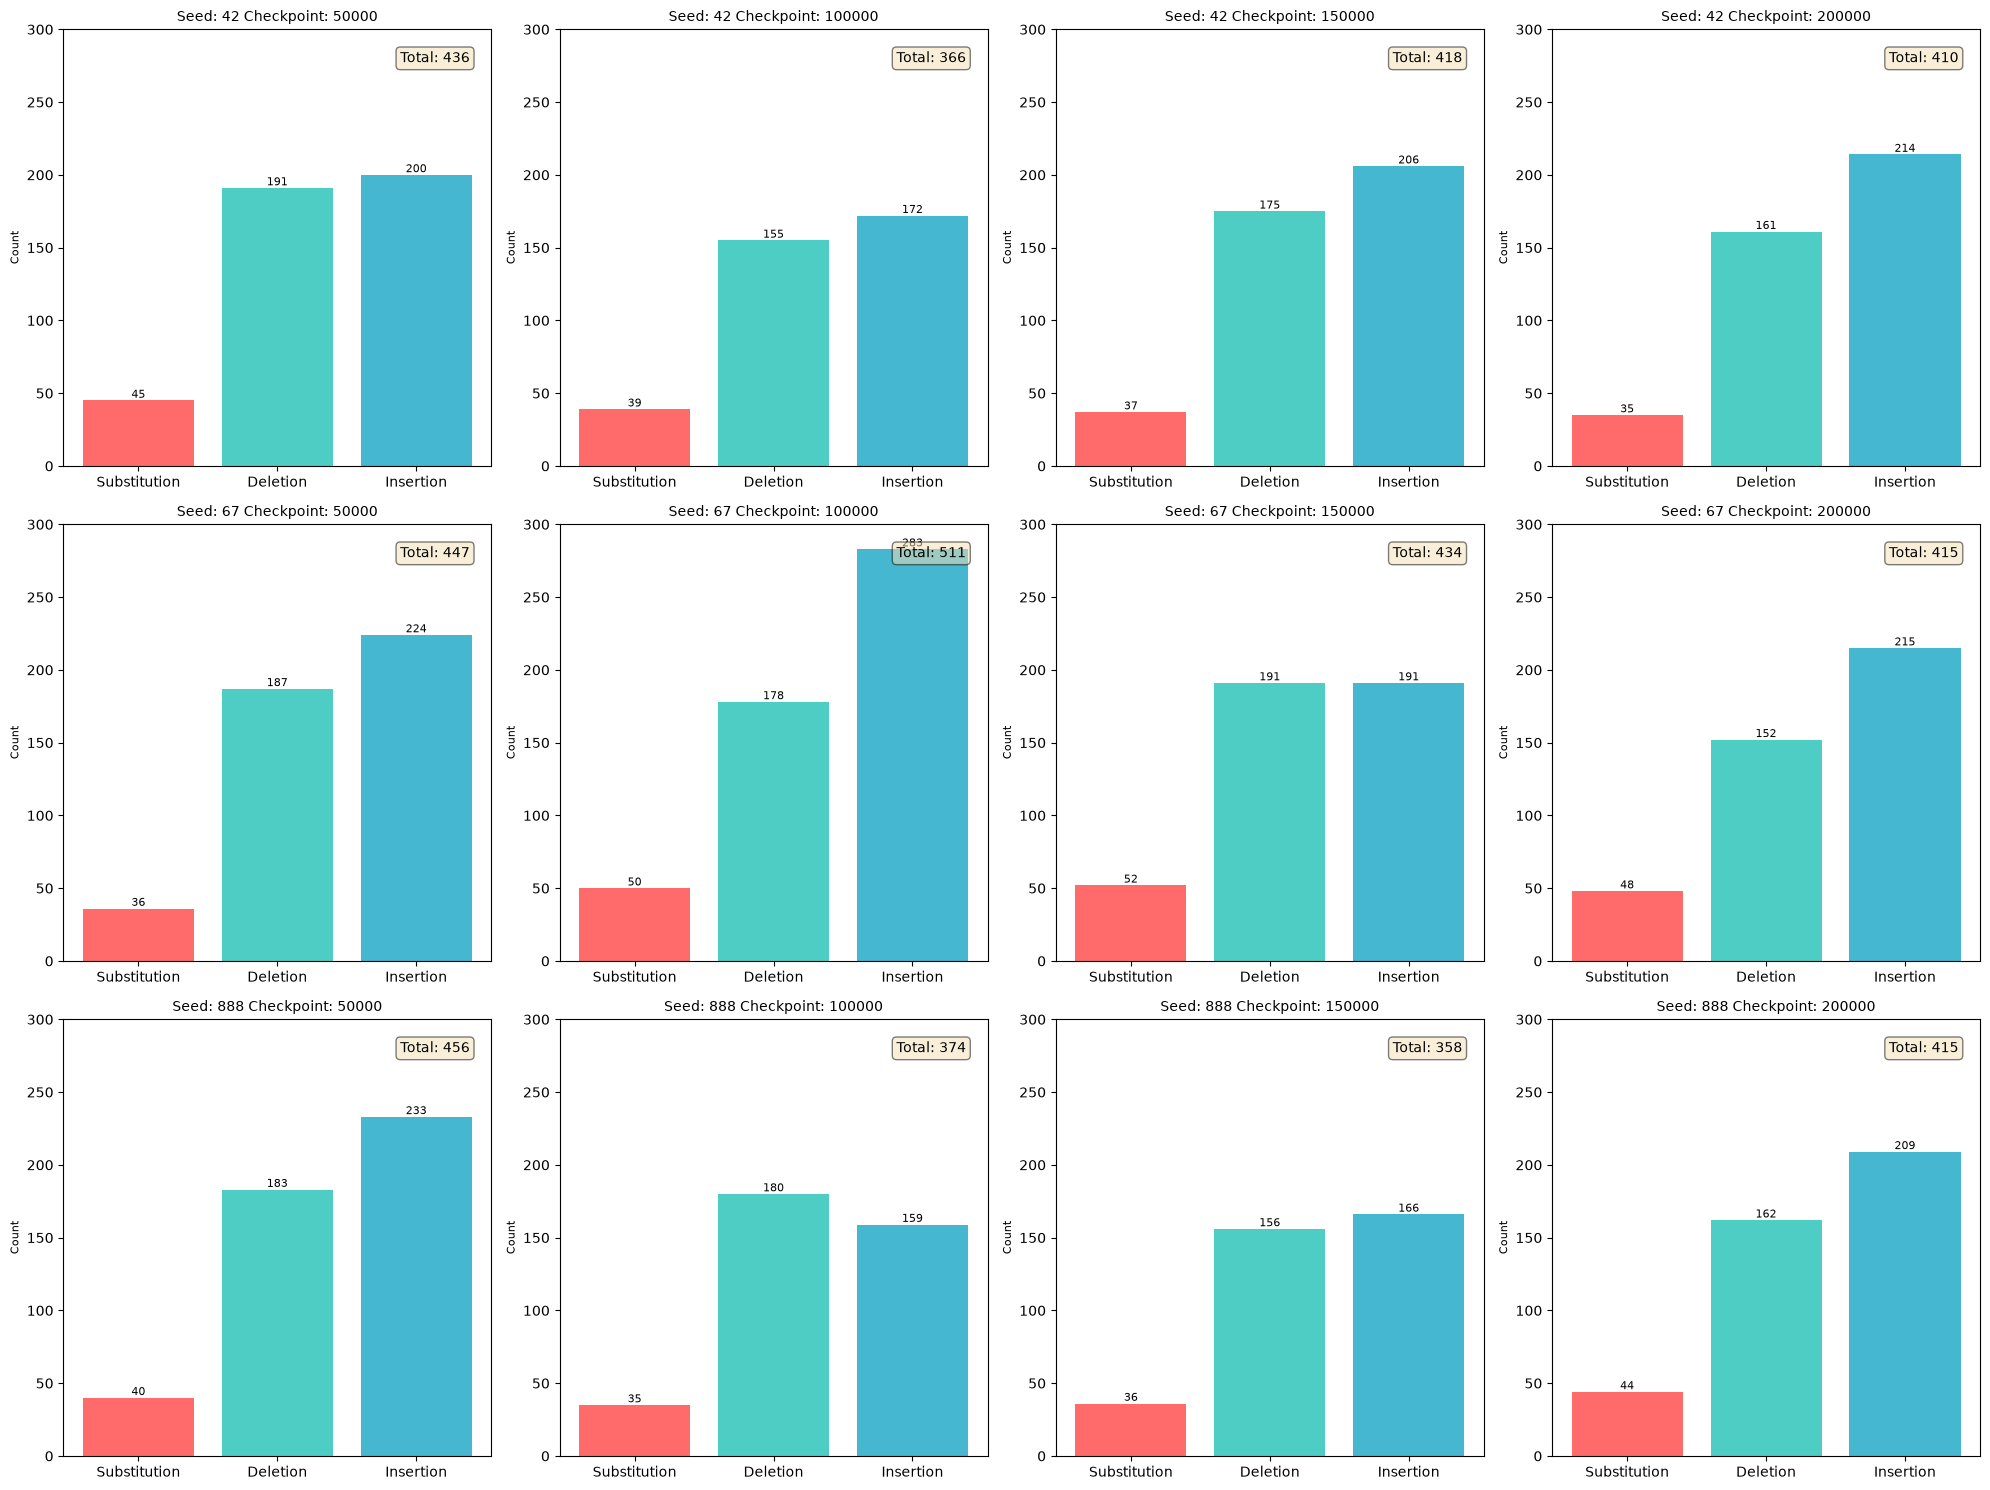

In [40]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, (ax, df) in enumerate(zip(axes, checkpoint_dfs)):
    refs_list = [str(x).strip().split() for x in df["target_ref"]]
    hyps_list = [str(x).strip().split() for x in df["model_hyp"]]
    refs_dict = dict(enumerate(refs_list))
    hyps_dict = dict(enumerate(hyps_list))
    
    err = collect_errors(refs_dict, hyps_dict)
    total_errors = err["n_sub"] + err["n_del"] + err["n_ins"]
    
    #bar chart
    error_types = ['Substitution', 'Deletion', 'Insertion']
    counts = [err['n_sub'], err['n_del'], err['n_ins']]
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']
    bars = ax.bar(error_types, counts, color=colors)
    ax.set_title(f"Seed: {seed_ckpts[i][0]} Checkpoint: {seed_ckpts[i][1]}", fontsize=10)
    ax.set_ylabel('Count', fontsize=8)
    ax.set_ylim(0, 300)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom', fontsize=8)
    
    ax.text(0.95, 0.95, f'Total: {total_errors}', 
            transform=ax.transAxes, ha='right', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

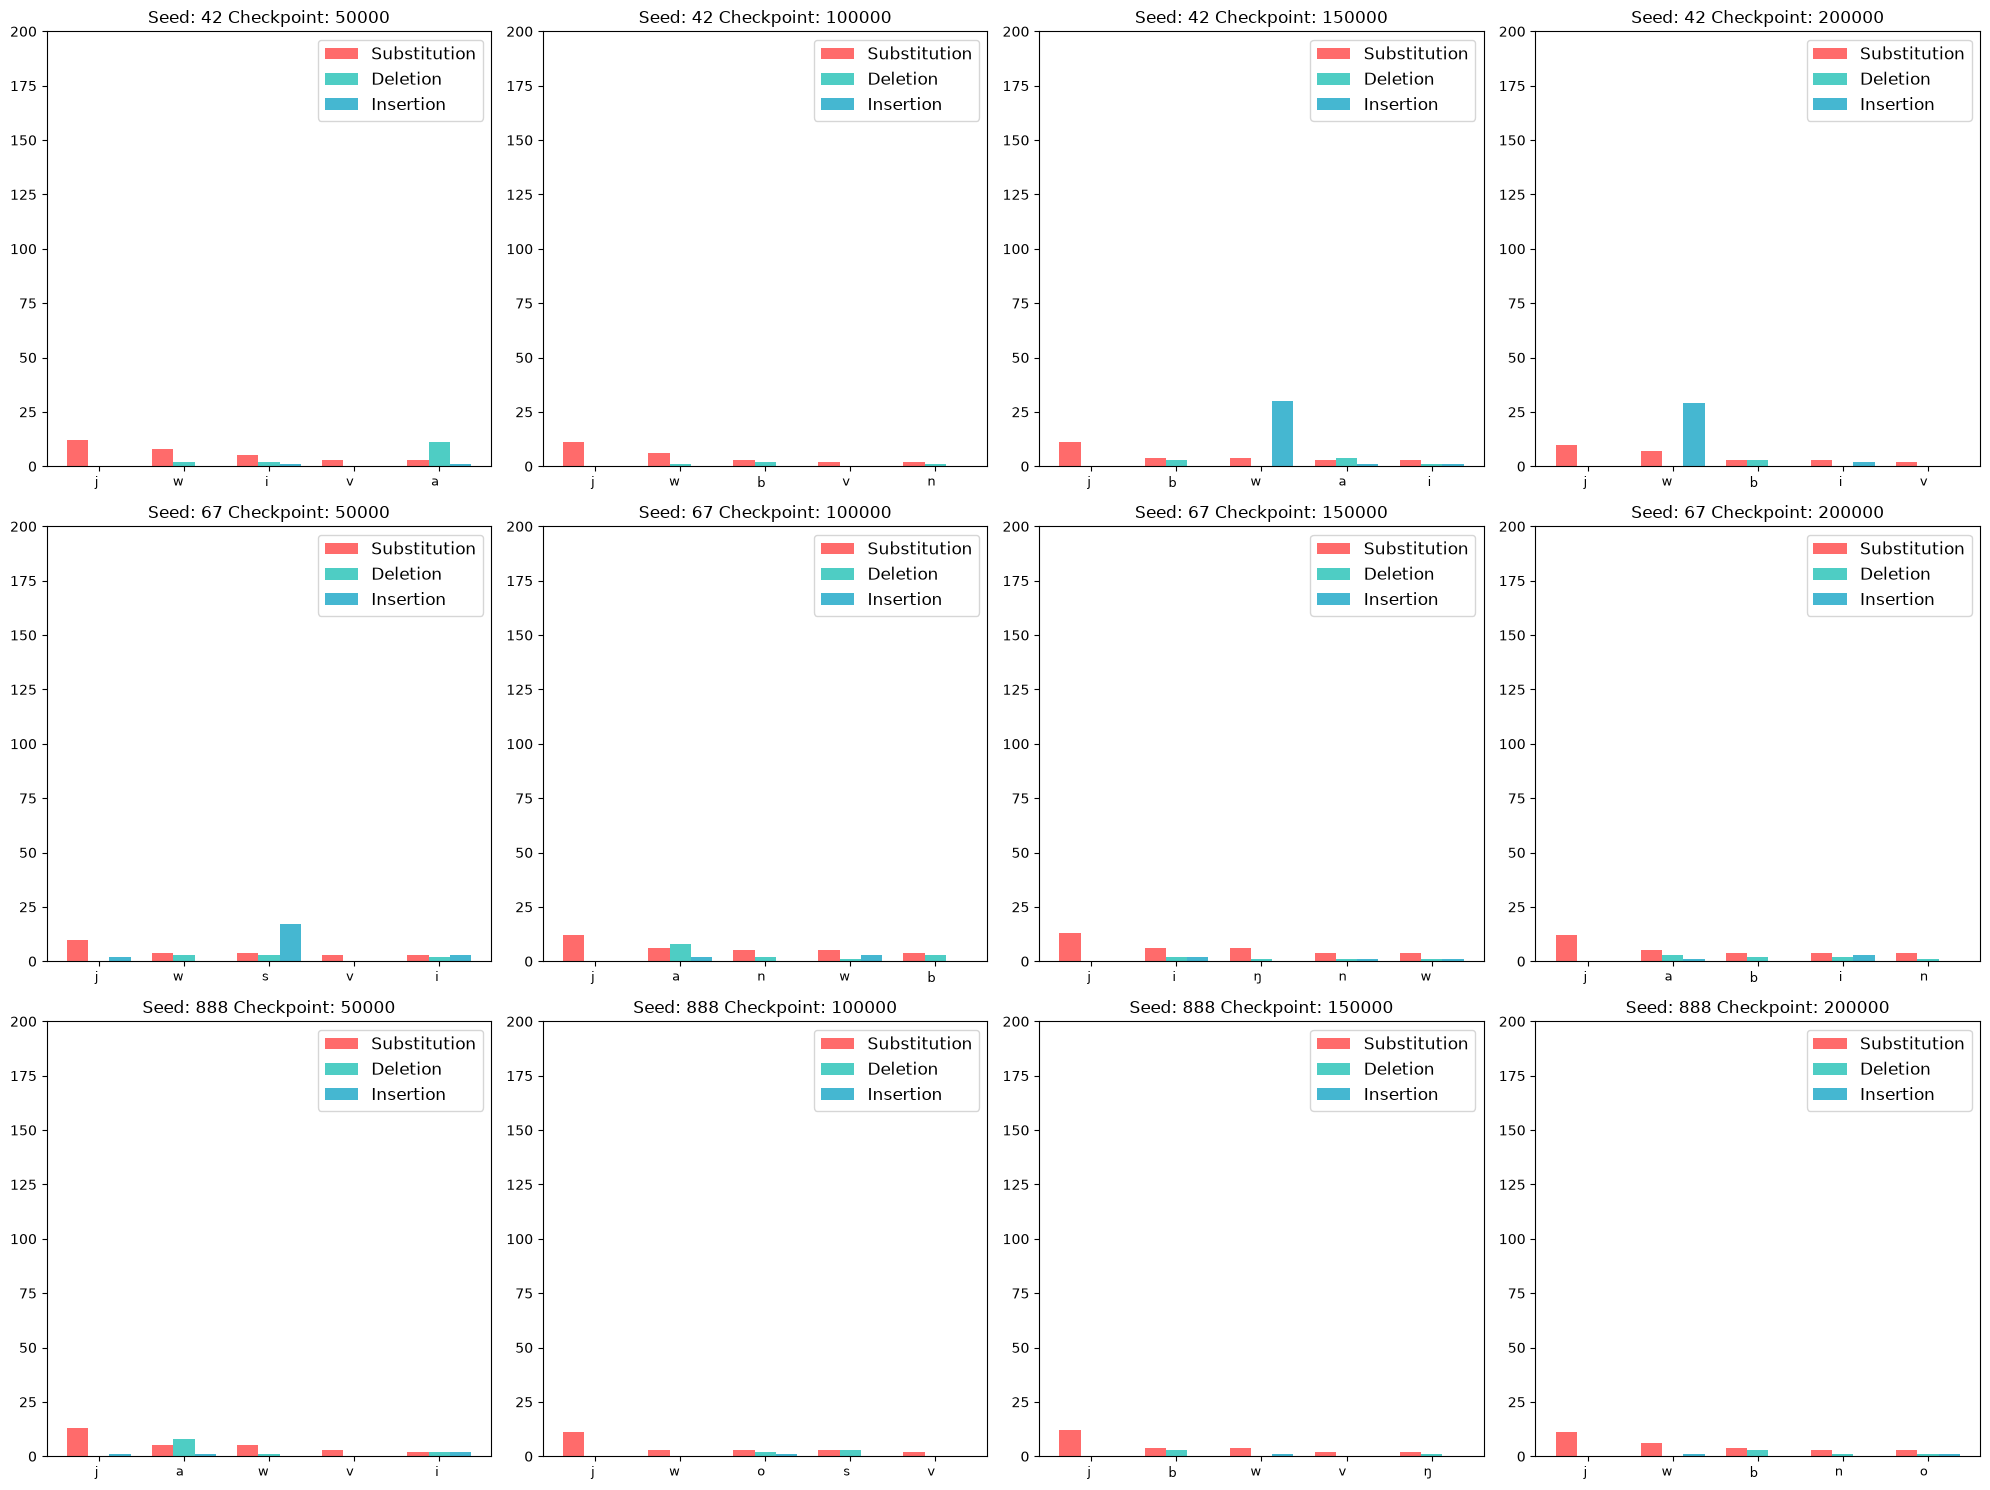

In [52]:
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

for i, (ax, df) in enumerate(zip(axes, checkpoint_dfs)):
    refs_list = [str(x).strip().split() for x in df["target_ref"]]
    hyps_list = [str(x).strip().split() for x in df["model_hyp"]]
    refs_dict = dict(enumerate(refs_list))
    hyps_dict = dict(enumerate(hyps_list))

    err = collect_errors(refs_dict, hyps_dict)
    substituted = err["sub_ref_counter"].most_common(5)
    deleted = err["del_counter"].most_common(5)
    inserted = err["ins_counter"].most_common(5)

    x = np.arange(5)
    width = 0.25

    sub_phones = [p for p, c in substituted]
    sub_counts = [c for p, c in substituted]
    del_counts = [err["del_counter"][p] for p in sub_phones]
    ins_counts = [err["ins_counter"][p] for p in sub_phones]

    ax.bar(x - width, sub_counts, width, label='Substitution', color='#FF6B6B')
    ax.bar(x, del_counts, width, label='Deletion', color='#4ECDC4')
    ax.bar(x + width, ins_counts, width, label='Insertion', color='#45B7D1')

    ax.set_title(f"Seed: {seed_ckpts[i][0]} Checkpoint: {seed_ckpts[i][1]}", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(sub_phones, ha='right', fontsize=9)
    ax.set_ylim(0, 200)
    ax.legend(fontsize=12, loc='upper right')
    
#for j in range(len(checkpoint_dfs), len(axes)):
#    axes[j].axis('off')


plt.tight_layout()
plt.show()

In [53]:
import pandas as pd

all_model_errors = {}
summary_rows = []

for seed in seeds:
  for ckpt in checkpoints:
    model_id = f'seed{seed}_ckpt{ckpt}'
    filepath = (f'../per_model/ckpt_seed{seed}_checkpoint{ckpt}_test_results.csv')

    df = pd.read_csv(filepath)

    refs_list = [str(x).strip().split() for x in df['target_ref']]
    hyps_list = [str(x).strip().split() for x in df['model_hyp']]
    refs_dict = dict(enumerate(refs_list))
    hyps_dict = dict(enumerate(hyps_list))

    err = collect_errors(refs_dict, hyps_dict)
    total_errors = err['n_sub'] + err['n_del'] + err['n_ins']

    all_model_errors[model_id] = err

    summary_rows.append({
        'Model': model_id,
        'Total Edits': total_errors,
        'Substitutions': err['n_sub'],
        'Sub %': (
            f"{err['n_sub'] / total_errors * 100:.1f}%"
            if total_errors > 0
            else '0.0%'
        ),
        'Deletions': err['n_del'],
        'Del %': (
            f"{err['n_del'] / total_errors * 100:.1f}%"
            if total_errors > 0
            else '0.0%'
        ),
        'Insertions': err['n_ins'],
        'Ins %': (
            f"{err['n_ins'] / total_errors * 100:.1f}%"
            if total_errors > 0
            else '0.0%'
        ),
    })

summary_df = pd.DataFrame(summary_rows).sort_values(by='Total Edits')

display(summary_df)

,Model,Total Edits,Substitutions,Sub %,Deletions,Del %,Insertions,Ins %
10,seed888_ckpt150000,358,36,10.1%,156,43.6%,166,46.4%
1,seed42_ckpt100000,366,39,10.7%,155,42.3%,172,47.0%
9,seed888_ckpt100000,374,35,9.4%,180,48.1%,159,42.5%
3,seed42_ckpt200000,410,35,8.5%,161,39.3%,214,52.2%
7,seed67_ckpt200000,415,48,11.6%,152,36.6%,215,51.8%
11,seed888_ckpt200000,415,44,10.6%,162,39.0%,209,50.4%
2,seed42_ckpt150000,418,37,8.9%,175,41.9%,206,49.3%
6,seed67_ckpt150000,434,52,12.0%,191,44.0%,191,44.0%
0,seed42_ckpt50000,436,45,10.3%,191,43.8%,200,45.9%
4,seed67_ckpt50000,447,36,8.1%,187,41.8%,224,50.1%


In [57]:
def top10(counter, label):
    print(f"--- {label} ---")
    return pd.DataFrame([{"Phone": p, "Count": c} for p, c in counter.most_common(10)])

for model, err in all_model_errors.items():
    print(f"----------------- SEPARATOR -----------------")
    print(f"Model: {model}")
    print('\nRef phones most often substituted:')
    display(top10(err['sub_ref_counter'], 'REF phones replaced'))

    print('\nRef phones most often deleted:')
    display(top10(err['del_counter'], 'REF phones dropped'))

    print('\nPhones most often inserted:')
    display(top10(err['ins_counter'], 'phones added'))

----------------- SEPARATOR -----------------
Model: seed42_ckpt50000

Ref phones most often substituted:
--- REF phones replaced ---


,Phone,Count
0,j,12
1,w,8
2,i,5
3,v,3
4,a,3
5,s,3
6,t͡ʃ,3
7,ŋ,2
8,o,2
9,e,2



Ref phones most often deleted:
--- REF phones dropped ---


,Phone,Count
0,ʔ,137
1,a,11
2,n,5
3,o,5
4,s,4
5,k,4
6,t,3
7,p,3
8,ɡ,3
9,b,3



Phones most often inserted:
--- phones added ---


...

,Phone,Count
0,j,11
1,w,6
2,b,4
3,n,3
4,o,3
5,t͡ʃ,3
6,a,3
7,v,2
8,s,2
9,i,2



Ref phones most often deleted:
--- REF phones dropped ---


,Phone,Count
0,ʔ,141
1,a,5
2,k,3
3,b,3
4,ŋ,2
5,s,2
6,d͡ʒ,1
7,o,1
8,p,1
9,ɡ,1



Phones most often inserted:
--- phones added ---


,Phone,Count
0,ʔ,147
1,ɡ,53
2,t,2
3,u,2
4,o,1
5,h,1
6,k,1
7,w,1
8,i,1
